HOMEWORK 2

In [99]:
# Dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Getting the data

In [100]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

In [101]:
df_sel = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df_sel.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


**fuel_efficiency_mpg** distribution

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

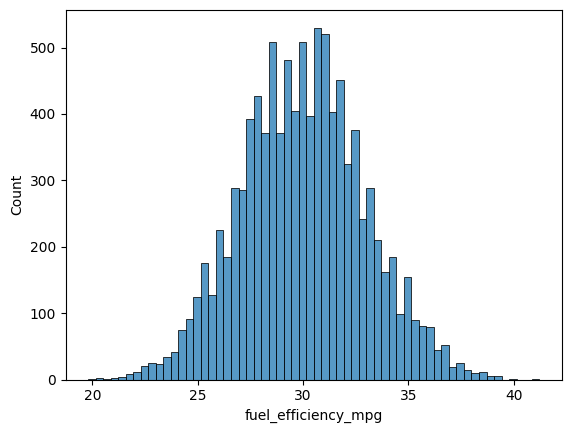

In [102]:
sns.histplot(df_sel['fuel_efficiency_mpg'])

In [103]:
print("The median is: " + str(df_sel['fuel_efficiency_mpg'].median()) + " and the mean is " + str(df_sel['fuel_efficiency_mpg'].mean()))

The median is: 30.0 and the mean is 29.9977


The distribution of fuel_efficiency_mpg shows a slight right skew; however, since the mean and median are close to each other, the overall shape is approximately normal.

**Q1. There's one column with missing values. What is it?**

Answer: column **horsepower**

In [104]:
df_sel.isnull().sum()

,0
engine_displacement,0
horsepower,877
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


**Q2. What's the median (50% percentile) for variable 'horsepower'?**

Answer: **254**

In [105]:
df_sel['horsepower'].median()

254.0

----------------------------------

Functions for LR

In [106]:
def prepare_X(df, fillna_value=0):
    df_num = df.fillna(fillna_value)
    X = df_num[['engine_displacement','horsepower','vehicle_weight','model_year']].values
    ones = np.ones(X.shape[0])
    return np.column_stack([ones, X])

def train_linear_regression(X, y, r=0.0):
    XTX = X.T.dot(X)

    # Regularization, keep r = 0.0 for LR without regularization
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w

def predict(X, w):
    return X.dot(w)

def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred)**2))

Preparing and splitting dataset

In [107]:
n = len(df_sel)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_sel.iloc[idx[:n_train]]
df_val = df_sel.iloc[idx[n_train:n_train + n_val]]
df_test = df_sel.iloc[idx[n_train + n_val:]]

----------------------------------

**Q3. Two options of imputation for variable 'horsepower'. Which option gives better RMSE?**

Answer: The difference is so small, I would say both are equally good in this case.

* Imputation with zeros



In [108]:
df_train_zeros = df_train.fillna(0)
df_val_zeros = df_val.fillna(0)

X_train = prepare_X(df_train_zeros)
y_train = df_train_zeros['fuel_efficiency_mpg'].values
X_val = prepare_X(df_val_zeros)
y_val = df_val_zeros['fuel_efficiency_mpg'].values

w0 = train_linear_regression(X_train, y_train, r=0.0)
rmse_zero = rmse(y_val, predict(X_val, w0))

* Imputation with the variable mean

In [109]:
df_train_mean = df_train.fillna({'horsepower': df_train['horsepower'].mean()})
df_val_mean = df_val.fillna({'horsepower': df_train['horsepower'].mean()})

X_train = prepare_X(df_train_mean)
y_train = df_train_mean['fuel_efficiency_mpg'].values
X_val = prepare_X(df_val_mean)
y_val = df_val_mean['fuel_efficiency_mpg'].values

w_mean = train_linear_regression(X_train, y_train, r=0.0)
rmse_mean = rmse(y_val, predict(X_val, w_mean))

Comparing RMSE scores

In [110]:
print("RMSE with zeros:", round(rmse_zero,3))
print("RMSE with mean:", round(rmse_mean,3))

RMSE with zeros: 2.205
RMSE with mean: 2.202


**Q4. Regularized linear regression. Which r gives the best RMSE?**

Answer: Zero. When trained with different r values, the smallest RMSE value was r = 0 RMSE = 2.2053

In [111]:
df_train_zeros = df_train.fillna(0)
df_val_zeros = df_val.fillna(0)

X_train = prepare_X(df_train_zeros)
y_train = df_train_zeros['fuel_efficiency_mpg'].values
X_val = prepare_X(df_val_zeros)
y_val = df_val_zeros['fuel_efficiency_mpg'].values

# Using different r values

for r in [0, 0.01, 0.1, 1, 5, 10, 100]: # Values provided in homework 2
    w = train_linear_regression(X_train, y_train, r=r)
    y_pred = predict(X_val, w)
    score = rmse(y_val, y_pred)
    print("r =", r, "RMSE =", round(score,4))

r = 0 RMSE = 2.2053
r = 0.01 RMSE = 2.2058
r = 0.1 RMSE = 2.2241
r = 1 RMSE = 2.3492
r = 5 RMSE = 2.4094
r = 10 RMSE = 2.4195
r = 100 RMSE = 2.4292


**Q5. Multiple seeds for data splitting. What's the standard deviation of all the scores?**

Answer: Standard deviation: 0.029

In [112]:
scores = [] # A list to collect RMSE values
for seed in range(10):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df_sel.iloc[idx[:n_train]]
    df_val = df_sel.iloc[idx[n_train:n_train+n_val]]

    X_train = prepare_X(df_train, fillna_value=0)
    y_train = df_train['fuel_efficiency_mpg'].values
    X_val = prepare_X(df_val, fillna_value=0)
    y_val = df_val['fuel_efficiency_mpg'].values

    w = train_linear_regression(X_train, y_train, r=0.0) # Homework said to train without regularization
    scores.append(rmse(y_val, predict(X_val, w)))

print("Standard deviation:", round(np.std(scores),3)) # SD of all RMSE values collected

Standard deviation: 0.029


**Q6. Combining train and validation dataset, seed 9, imputation with zeros, r=0.001. What's the RMSE on the test dataset?**

Answer: RMSE test: 2.236

In [113]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_sel.iloc[idx[:n_train]]
df_val = df_sel.iloc[idx[n_train:n_train+n_val]]
df_test = df_sel.iloc[idx[n_train+n_val:]]

df_full = pd.concat([df_train, df_val])

X_train = prepare_X(df_full, fillna_value=0)
y_train = df_full['fuel_efficiency_mpg'].values
X_test = prepare_X(df_test, fillna_value=0)
y_test = df_test['fuel_efficiency_mpg'].values

w = train_linear_regression(X_train, y_train, r=0.001)
rmse_test = rmse(y_test, predict(X_test, w))
print("RMSE test:", round(rmse_test,3))

RMSE test: 2.236
